# Test3 --- Poisson Neural Posterior Estimation 

In [1]:
import numpy as np

In [2]:
import torch
from sbi.inference import NPE

In [3]:
import corner as DFM
import matplotlib.pyplot as plt

In [4]:
from px2cosmo import util as UT

In [5]:
params = np.loadtxt("/Users/chang/data/px2cosmo/test3/mock3_N50000.counts_params.dat")
counts = np.loadtxt("/Users/chang/data/px2cosmo/test3/mock3_N50000.counts.dat")

In [6]:
params.shape

(50000, 5)

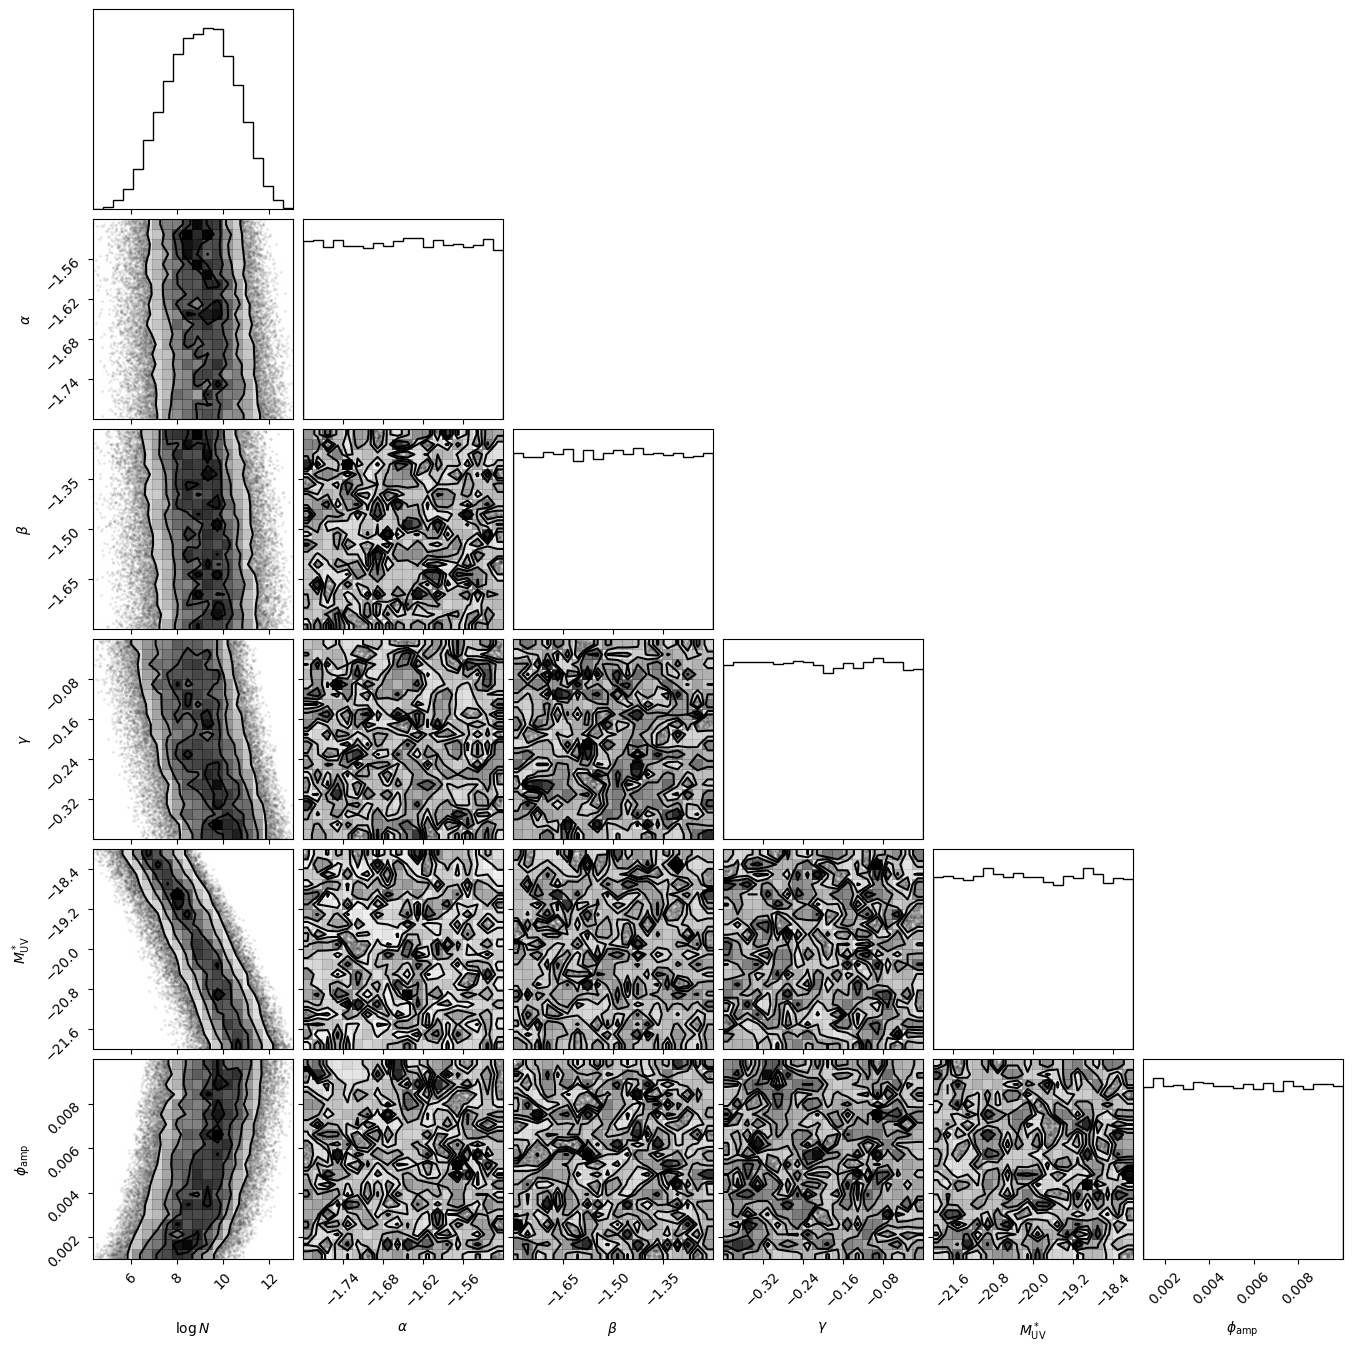

In [7]:
fig = DFM.corner(np.hstack([np.log(counts)[:,None], params]), 
                 labels=[r'$\log N$', r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\phi_{\rm amp}$'])

In [8]:
bounds = np.array([[-1.8, -1.5], [-1.8, -1.2], [-0.4, 0.], [-22., -18.], [1e-3, 1e-2]])

In [9]:
params_t = UT.inv_cdf_transform(params, bounds.T)

In [10]:
ishuffle = np.arange(params_t.shape[0])
np.random.shuffle(ishuffle)

_phi = torch.tensor(params_t[ishuffle][:int(counts.shape[0]*0.9)].astype(np.float32))#.to('mps')
_logcounts = torch.tensor(np.log(counts)[ishuffle][:int(counts.shape[0]*0.9)].astype(np.float32)[:,None])#.to('mps')

In [11]:
inference = NPE(density_estimator='zuko_maf')#, device='mps')
_ = inference.append_simulations(_phi, _logcounts).train()

p_phi_logN = inference.build_posterior()

 Neural network successfully converged after 101 epochs.

/opt/homebrew/Caskroom/miniconda/base/envs/jwst/lib/python3.14/site-packages/sbi/inference/potentials/posterior_based_potential.py:58: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(


In [12]:
inference.summary['best_validation_loss'][0]

2.737492183338512

## validate

In [13]:
test_phi = torch.tensor(params[ishuffle][int(counts.shape[0]*0.9):].astype(np.float32))#.to('mps')
test_logcounts = torch.tensor(np.log(counts)[ishuffle][int(counts.shape[0]*0.9):].astype(np.float32)[:,None])#.to('mps')

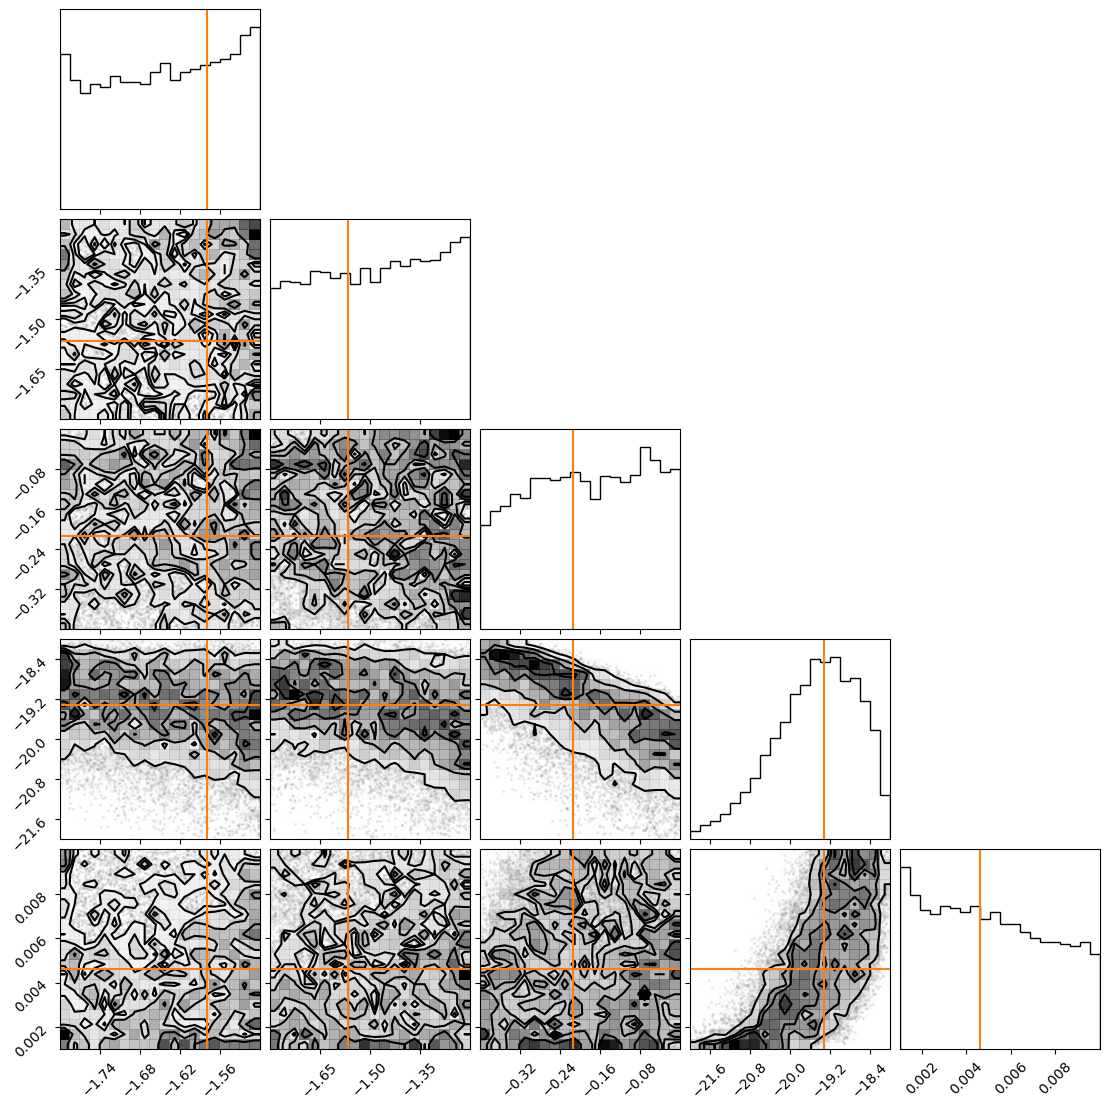

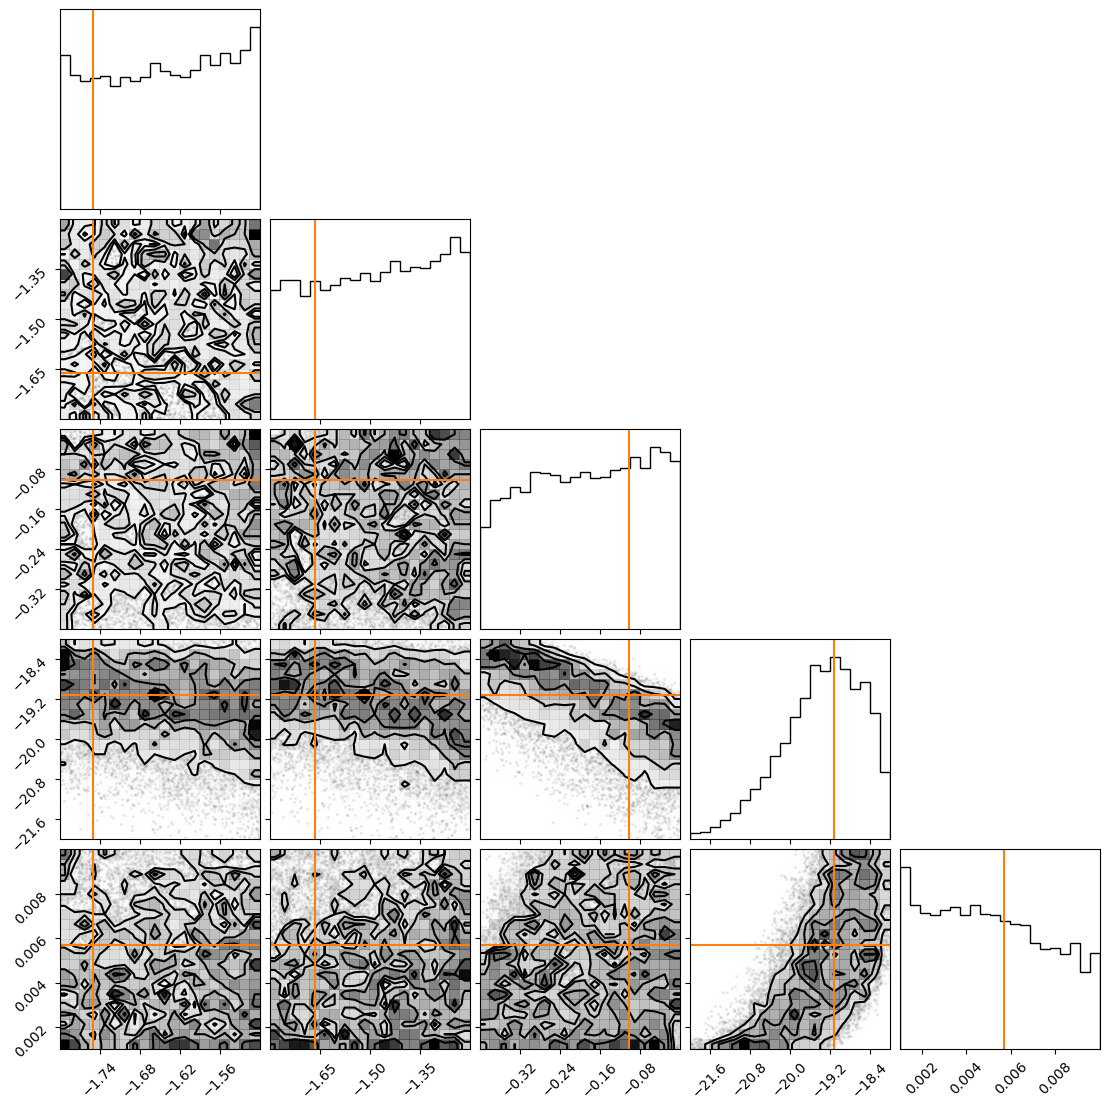

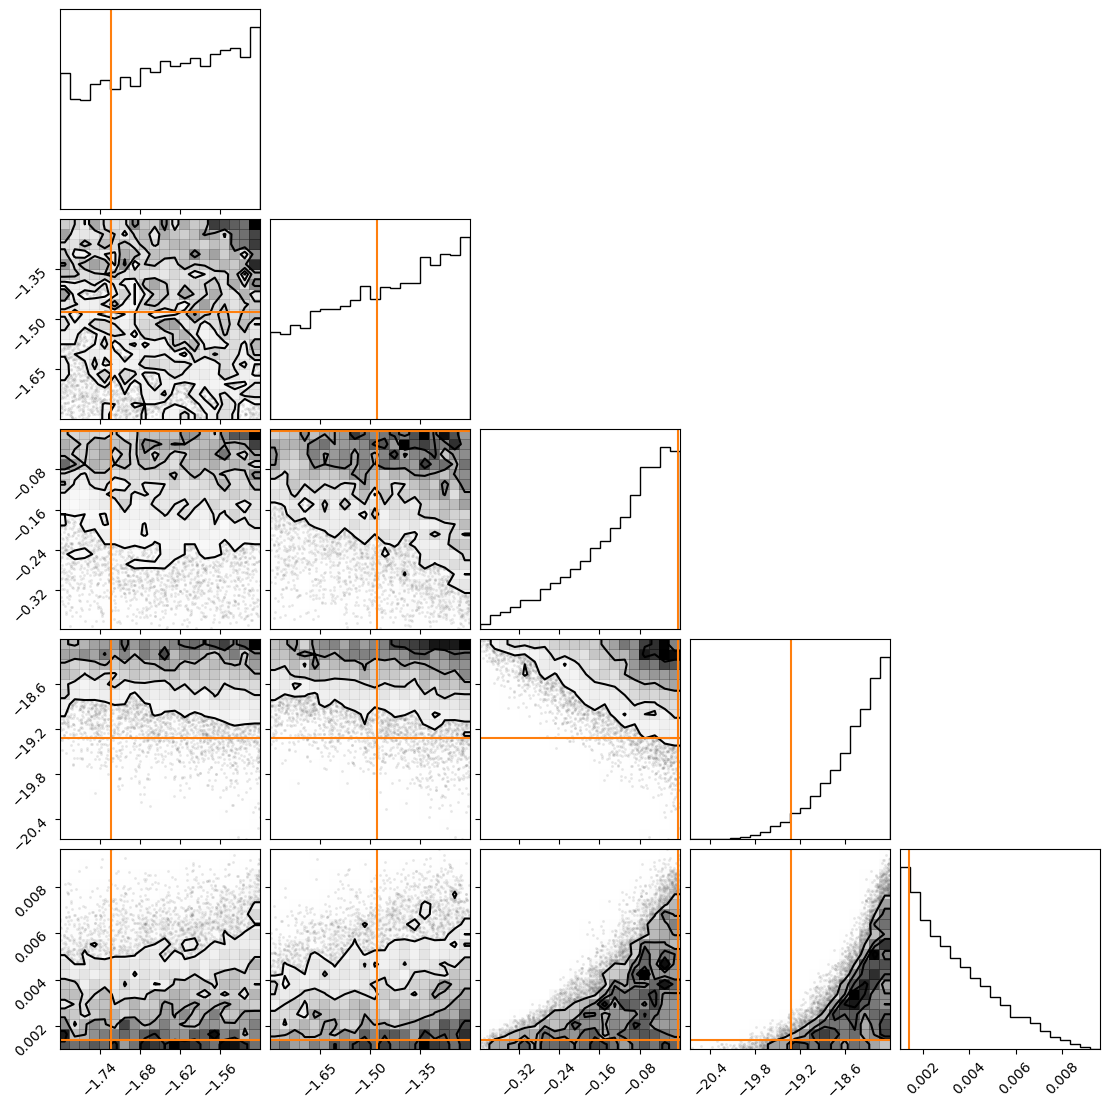

In [14]:
for i in range(3):
    _samples_t = p_phi_logN.sample((10000,), x=test_logcounts[i], show_progress_bars=False).cpu().numpy()
    _samples = UT.cdf_transform(_samples_t, bounds.T)
    
    fig = DFM.corner(_samples)
    DFM.overplot_lines(fig, test_phi[i].numpy(), color='C1')
    plt.show()

In [15]:
test_samples_t = p_phi_logN.sample_batched((1000,), x=test_logcounts, show_progress_bars=False)

/var/folders/4_/4m4zwzzs30518t13kpqjy7k80000gn/T/ipykernel_13650/3220614438.py:1: UserWarning: Note that for batched sampling, the direct posterior sampling generates 5000 * 1000 = 5000000 samples. This can be slow and memory-intensive. Consider reducing the number of samples or batch size.
  test_samples_t = p_phi_logN.sample_batched((1000,), x=test_logcounts, show_progress_bars=False)
/var/folders/4_/4m4zwzzs30518t13kpqjy7k80000gn/T/ipykernel_13650/3220614438.py:1: UserWarning: Capping max_sampling_batch_size from 10000 to 20 to avoid excessive memory usage.
  test_samples_t = p_phi_logN.sample_batched((1000,), x=test_logcounts, show_progress_bars=False)


In [17]:
test_samples = UT.cdf_transform(test_samples_t, bounds.T)

In [19]:
import tarp

In [20]:
ecp, alpha = tarp.get_tarp_coverage(test_samples.cpu().numpy(), test_phi.cpu().numpy())

Text(0.5, 0, 'Credibility Level')

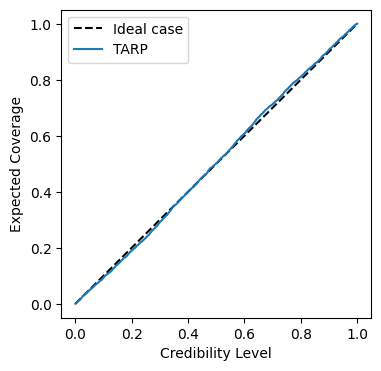

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.plot([0, 1], [0, 1], ls='--', color='k', label = "Ideal case")
ax.plot(alpha, ecp, label='TARP')
ax.legend()
ax.set_ylabel("Expected Coverage")
ax.set_xlabel("Credibility Level")

# further validation against ABC

In [22]:
from px2cosmo import fm as FM 
from px2cosmo import util as UT

In [23]:
phi_true = np.array([-1.65, -1.5, -0.2, -19.5, 6e-3]) # fit by eye to zeus21 output

# sample LF 
X_obs = FM.forwardmodel(phi_true[:4], name='test2', phi_amp=phi_true[-1])

In [24]:
N_obs = X_obs.shape[0]
print(N_obs)

6363


In [25]:
_samples_t = p_phi_logN.sample((10000,), x=torch.tensor([np.log(N_obs)]), show_progress_bars=False).cpu().numpy()
_samples = UT.cdf_transform(_samples_t, bounds.T)

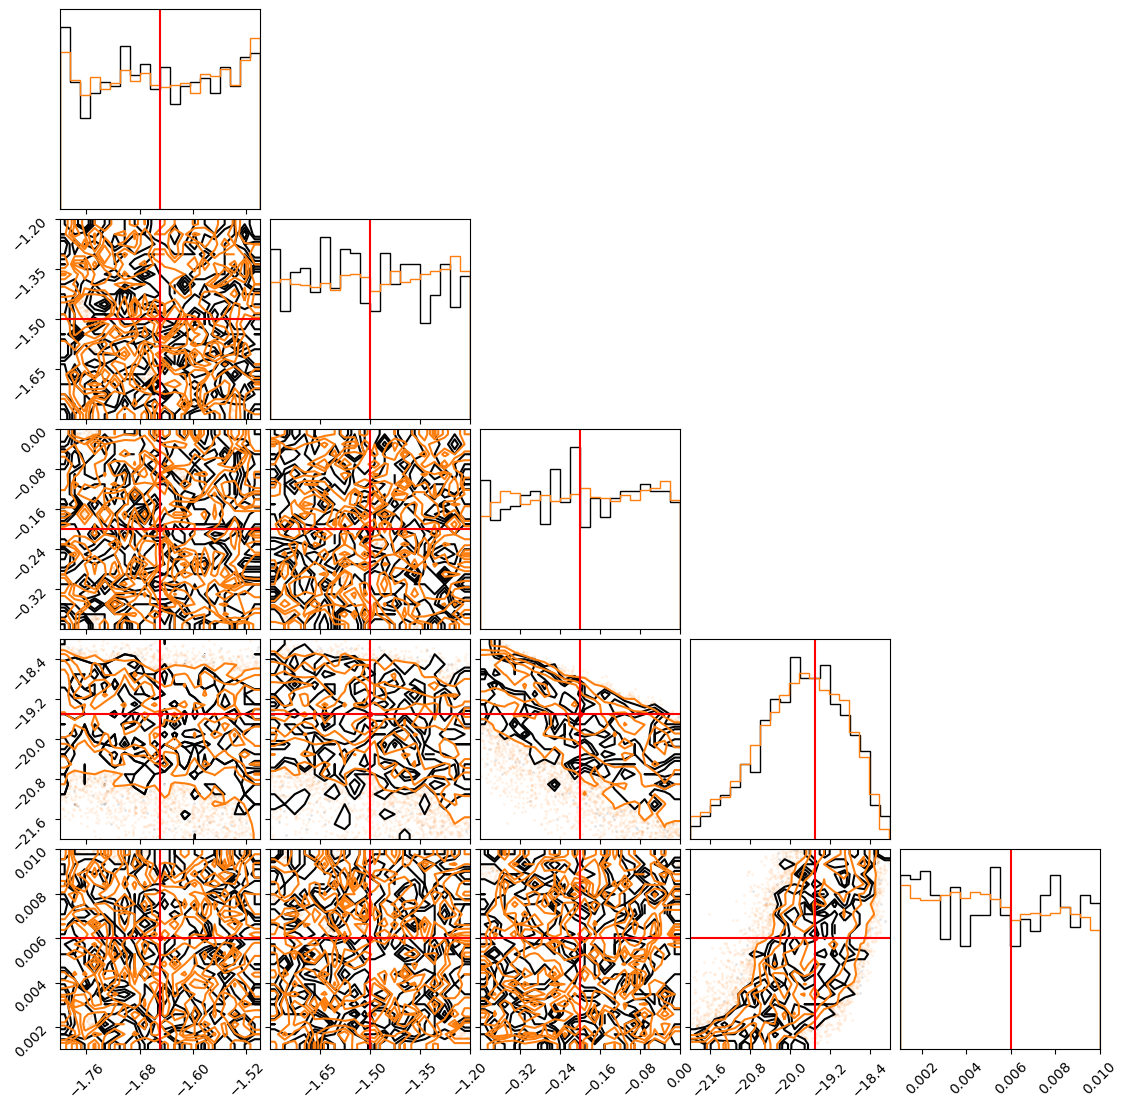

In [26]:
fig = DFM.corner(params[np.abs(counts - N_obs) < 200], range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, plot_density=False)
fig = DFM.corner(_samples, fig=fig, color='C1',
                 hist_kwargs={'density': True}, plot_density=False)
DFM.overplot_points(fig, [phi_true], color='red')
DFM.overplot_lines(fig, phi_true, color='red')
#DFM.overplot_lines(fig, np.median(sampler.flatchain[5000:,:], axis=0), color='blue')

In [27]:
torch.save(p_phi_logN, '/Users/chang/data/px2cosmo/test3/mock3_p_phit_logN.pt')